# Tutorial 4: Galactic Priors and Models

This tutorial explores the prior probability distributions used in brutus for modeling stars in the Milky Way context.

## Topics Covered

1. **Galactic structure priors** (thin disk, thick disk, halo)
2. **3D dust priors** with Bayestar
3. **Distance and parallax priors**
4. **Prior factorization** and combination
5. **Metallicity and age-metallicity priors**

## Prerequisites

This tutorial requires the following brutus data files:
- `nn_c3k.h5` - Neural network for bolometric corrections
- `MIST_1.2_iso_vvcrit0.0.h5` - MIST isochrones
- `bayestar2019_v1.h5` (optional) - Bayestar dust map

If you don't have these files, run the optional download cell below.

In [1]:
# Optional: Download required data files (only needed if not already cached)
# Uncomment the lines below to download them.

# from brutus.data import fetch_isos, fetch_nns, fetch_dustmaps
# fetch_isos()       # ~200 MB -- MIST isochrones
# fetch_nns()        # ~50 MB  -- Neural network for bolometric corrections
# fetch_dustmaps()   # ~2 GB   -- Bayestar 3D dust map (optional)

In [2]:
# Imports and setup
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from tutorial_utils import (
    setup_tutorial,
    find_brutus_data_file,
    save_figure as _save_fig,
    print_section,
)

info = setup_tutorial(4, title="Tutorial 04: Galactic Priors and Models")
plots_dir = info['plot_dir']


def save_figure(fig, name):
    """Save figure to this tutorial's plot directory."""
    _save_fig(fig, 4, name)


Tutorial 04: Galactic Priors and Models

Checking data requirements for Tutorial 4
  Found: nn_c3k.h5
  Found: MIST_1.2_iso_vvcrit0.0.h5
  Found: bayestar2019_v1.h5

  All required files available


## Section 1: Galactic Structure - 3D Density Models

The Galaxy has distinct structural components with different spatial distributions, ages, and metallicities.

### Components

- **Thin Disk**: Scale height ~300 pc, young/metal-rich stars
- **Thick Disk**: Scale height ~900 pc, old/metal-poor stars  
- **Halo**: Power-law profile, very old/metal-poor stars

Each component dominates at different Galactic latitudes and distances.

Computing Galactic priors for different sightlines...


  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_04/galactic_structure.png


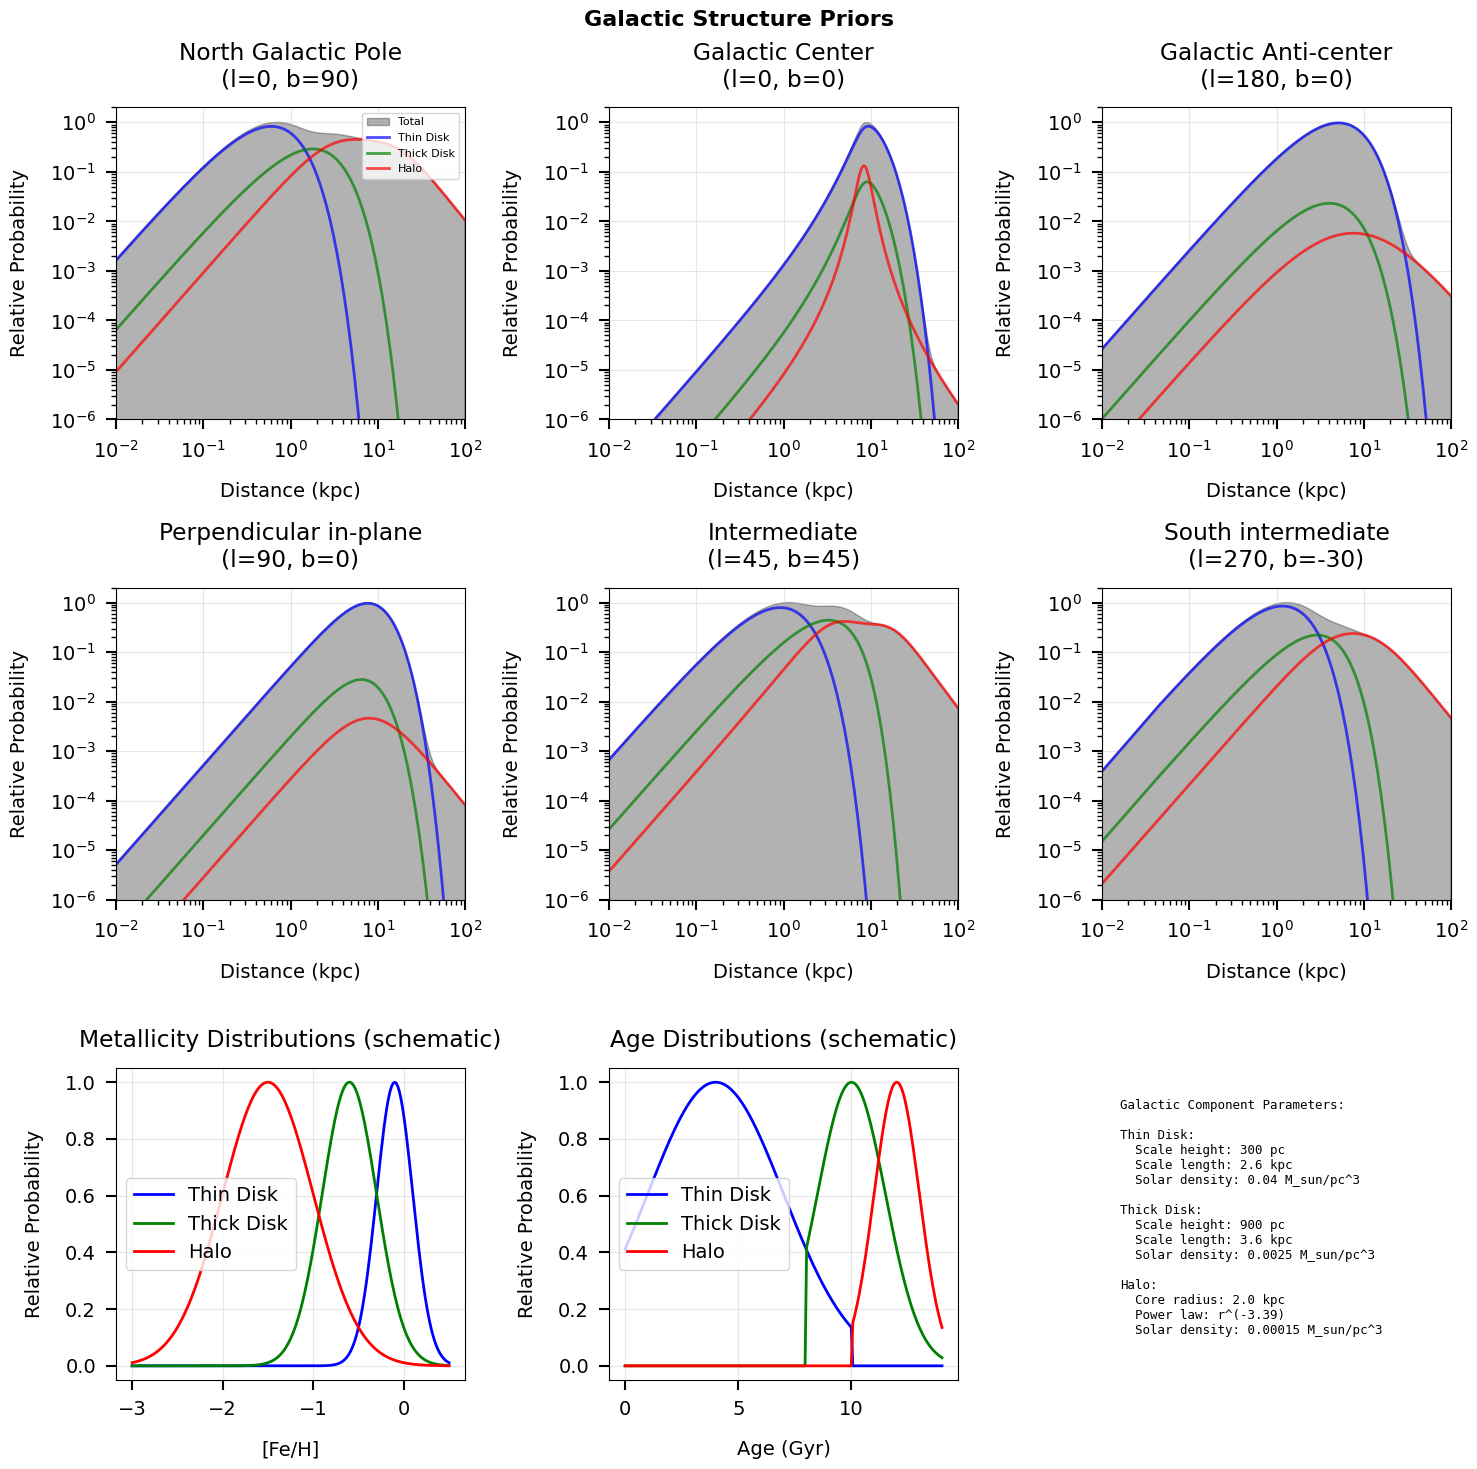


Galactic structure prior demonstrations complete
  Key points:
  - Thin disk dominates at low latitudes
  - Halo becomes important at high latitudes and large distances
  - Each component has distinct [Fe/H] and age distributions


In [3]:
from brutus.priors.galactic import logp_galactic_structure, logn_disk, logn_halo

# Create Galactic structure visualization  
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

# Define sightlines
sightlines = [
    (0, 90, 'North Galactic Pole'),
    (0, 0, 'Galactic Center'),
    (180, 0, 'Galactic Anti-center'),
    (90, 0, 'Perpendicular in-plane'),
    (45, 45, 'Intermediate'),
    (270, -30, 'South intermediate')
]

# Distance grid
distances = np.logspace(-2, 2, 200)  # 0.01 to 100 kpc

print("Computing Galactic priors for different sightlines...")

for idx, (l, b, title) in enumerate(sightlines[:6]):
    ax = axes[idx // 3, idx % 3]
    
    coord = np.array([l, b])
    
    # Get prior
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        lnp = logp_galactic_structure(distances, coord)
    
    # Convert to cylindrical coordinates for component visualization
    from astropy.coordinates import SkyCoord, CylindricalRepresentation as CylRep
    import astropy.units as units
    
    ell = np.full_like(distances, l)
    b_arr = np.full_like(distances, b)
    coords = SkyCoord(l=ell * units.deg, b=b_arr * units.deg,
                     distance=distances * units.kpc, frame='galactic')
    coords_cyl = coords.galactocentric.cartesian.represent_as(CylRep)
    R, Z = coords_cyl.rho.value, coords_cyl.z.value
    
    # Compute individual components
    vol_factor = 2 * np.log(distances + 1e-300)
    lnp_thin = logn_disk(R, Z, R_scale=2.6, Z_scale=0.3) + vol_factor
    lnp_thick = logn_disk(R, Z, R_scale=2.0, Z_scale=0.9) + vol_factor + np.log(0.04)
    lnp_halo = logn_halo(R, Z) + vol_factor + np.log(0.005)
    
    # Convert to probabilities
    p_total = np.exp(lnp - np.max(lnp))
    p_thin = np.exp(lnp_thin - np.max(lnp))
    p_thick = np.exp(lnp_thick - np.max(lnp))
    p_halo = np.exp(lnp_halo - np.max(lnp))
    
    # Plot components
    ax.fill_between(distances, p_total, alpha=0.3, color='black', label='Total')
    ax.loglog(distances, p_thin, 'b-', lw=2, alpha=0.7, label='Thin Disk')
    ax.loglog(distances, p_thick, 'g-', lw=2, alpha=0.7, label='Thick Disk')
    ax.loglog(distances, p_halo, 'r-', lw=2, alpha=0.7, label='Halo')
    
    ax.set_xlabel('Distance (kpc)')
    ax.set_ylabel('Relative Probability')
    ax.set_title(f'{title}\n(l={l}, b={b})')
    ax.set_xlim(0.01, 100)
    ax.set_ylim(1e-6, 2)
    ax.grid(True, alpha=0.3)
    
    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')

# Panel 7: Metallicity distributions
ax = axes[2, 0]

feh_range = np.linspace(-3, 0.5, 200)

# Component metallicity distributions (schematic)
thin_feh = np.exp(-(feh_range + 0.1)**2 / (2 * 0.2**2))
thick_feh = np.exp(-(feh_range + 0.6)**2 / (2 * 0.3**2))
halo_feh = np.exp(-(feh_range + 1.5)**2 / (2 * 0.5**2))

ax.plot(feh_range, thin_feh/thin_feh.max(), 'b-', lw=2, label='Thin Disk')
ax.plot(feh_range, thick_feh/thick_feh.max(), 'g-', lw=2, label='Thick Disk')
ax.plot(feh_range, halo_feh/halo_feh.max(), 'r-', lw=2, label='Halo')

ax.set_xlabel('[Fe/H]')
ax.set_ylabel('Relative Probability')
ax.set_title('Metallicity Distributions (schematic)')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 8: Age distributions
ax = axes[2, 1]

age_range = np.linspace(0, 14, 200)  # Gyr

thin_age = np.exp(-(age_range - 4)**2 / (2 * 3**2)) * (age_range < 10)
thick_age = np.exp(-(age_range - 10)**2 / (2 * 1.5**2)) * (age_range > 8)
halo_age = np.exp(-(age_range - 12)**2 / (2 * 1**2)) * (age_range > 10)

ax.plot(age_range, thin_age/thin_age.max(), 'b-', lw=2, label='Thin Disk')
ax.plot(age_range, thick_age/thick_age.max(), 'g-', lw=2, label='Thick Disk')
ax.plot(age_range, halo_age/halo_age.max(), 'r-', lw=2, label='Halo')

ax.set_xlabel('Age (Gyr)')
ax.set_ylabel('Relative Probability')
ax.set_title('Age Distributions (schematic)')
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 9: Parameters text
ax = axes[2, 2]
ax.axis('off')

components_info = """
Galactic Component Parameters:

Thin Disk:
  Scale height: 300 pc
  Scale length: 2.6 kpc
  Solar density: 0.04 M_sun/pc^3

Thick Disk:
  Scale height: 900 pc
  Scale length: 3.6 kpc
  Solar density: 0.0025 M_sun/pc^3

Halo:
  Core radius: 2.0 kpc
  Power law: r^(-3.39)
  Solar density: 0.00015 M_sun/pc^3
"""

ax.text(0.05, 0.95, components_info, transform=ax.transAxes,
       fontsize=9, va='top', family='monospace')

plt.suptitle('Galactic Structure Priors', fontsize=16, fontweight='bold')
save_figure(fig, 'galactic_structure')
plt.show()

print("\nGalactic structure prior demonstrations complete")
print("  Key points:")
print("  - Thin disk dominates at low latitudes")
print("  - Halo becomes important at high latitudes and large distances")
print("  - Each component has distinct [Fe/H] and age distributions")

## Section 2: 3D Dust Extinction

The `Bayestar` class in `brutus.dust` provides distance-resolved extinction estimates. For any Galactic sightline, it returns A(V) mean and standard deviation as a function of distance, based on Pan-STARRS and 2MASS photometry.

Key properties:
- 120 distance bins from ~0.06 to ~60 kpc at ~7 arcmin HEALPix resolution
- A(V) uncertainty grows with distance
- Extinction concentrated near the Galactic plane
- Returns uniform prior for sightlines outside map coverage

The `logp_extinction` function wraps Bayestar queries to provide a Gaussian log-prior on A(V) at a given distance and sky position.

> **Coverage limitations:** Bayestar is based on Pan-STARRS photometry and has no
> coverage in the southern sky below declination ~ -30 degrees. Coverage is also
> incomplete near the Galactic center due to extreme crowding and extinction.
> For sightlines outside the map footprint, `logp_extinction` returns a uniform
> (uninformative) prior.

Loaded Bayestar dust map from /mnt/c/Users/joshs/Dropbox/GitHub/brutus/data/DATAFILES/bayestar2019_v1.h5

Querying Bayestar dust map for different sightlines...
  (l=  0, b= +0): max A(V) = 3.65
  (l= 90, b= +0): max A(V) = 3.93
  (l=180, b= +0): max A(V) = 2.99
  (l= 45, b=+30): max A(V) = 0.10
  (l=  0, b=+90): max A(V) = 0.01


  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_04/dust_extinction.png


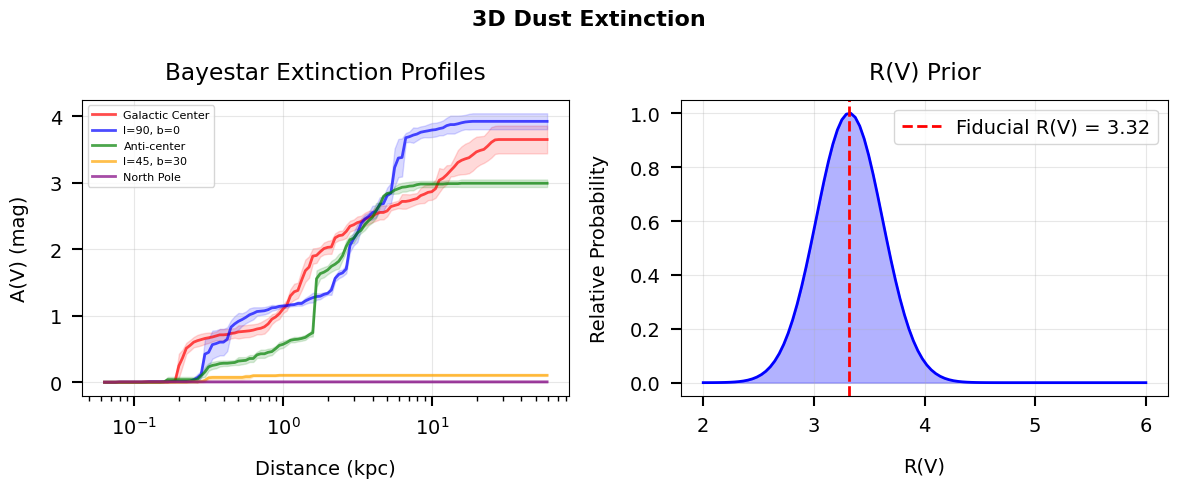


3D dust extinction demonstrations complete
  Key points:
  - Extinction increases with distance
  - Higher extinction near Galactic plane
  - Uncertainties grow with distance


In [4]:
# 3D Dust extinction demonstration using the Bayestar dust map
#
# The Bayestar class provides distance-resolved extinction profiles:
#   distances, av_mean, av_std = dustmap.query(coord)
# Each sightline returns A(V) as a function of distance.

# Try to load the real Bayestar dust map
dustmap = None
try:
    from brutus.dust import Bayestar
    dustfile = find_brutus_data_file('bayestar2019_v1.h5')
    dustmap = Bayestar(dustfile=dustfile)
    print(f"Loaded Bayestar dust map from {dustfile}")
    dust_available = True
except (FileNotFoundError, ImportError) as e:
    print(f"Bayestar dust map not available: {e}")
    print("  Using synthetic data for illustration.")
    dust_available = False

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Define sightlines for dust queries
sightlines_dust = [
    (0, 0, 'Galactic Center', 'red'),
    (90, 0, 'l=90, b=0', 'blue'),
    (180, 0, 'Anti-center', 'green'),
    (45, 30, 'l=45, b=30', 'orange'),
    (0, 90, 'North Pole', 'purple'),
]

# Panel 1: A(V) vs distance for different sightlines
ax = axes[0]

if dust_available:
    from astropy.coordinates import SkyCoord
    import astropy.units as units

    print("\nQuerying Bayestar dust map for different sightlines...")

    for l, b, label, color in sightlines_dust:
        coord = SkyCoord(l=l * units.deg, b=b * units.deg, frame='galactic')
        dists, av_mean, av_std = dustmap.query(coord)

        finite = np.isfinite(av_mean)
        if np.any(finite):
            ax.plot(dists[finite], av_mean[finite], color=color, lw=2,
                    alpha=0.7, label=label)
            ax.fill_between(dists[finite],
                            (av_mean - av_std)[finite],
                            (av_mean + av_std)[finite],
                            alpha=0.15, color=color)
            print(f"  (l={l:3d}, b={b:+3d}): max A(V) = {np.nanmax(av_mean):.2f}")

    ax.set_xlabel('Distance (kpc)')
    ax.set_ylabel('A(V) (mag)')
    ax.set_title('Bayestar Extinction Profiles')
    ax.set_xscale('log')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
else:
    # Synthetic fallback
    distances_synth = np.logspace(-1, 1.5, 100)
    for l, b, label, color in sightlines_dust:
        scale = np.exp(-abs(b) / 15.0)
        av_synth = 1.5 * scale * (1 - np.exp(-distances_synth / 2.0))
        ax.plot(distances_synth, av_synth, color=color, lw=2, alpha=0.7, label=label)
    ax.set_xlabel('Distance (kpc)')
    ax.set_ylabel('A(V) (mag)')
    ax.set_title('Extinction vs Distance (synthetic)')
    ax.set_xscale('log')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Panel 2: R(V) prior
ax = axes[1]

rv_values = np.linspace(2.0, 6.0, 100)
rv_prob = np.exp(-(rv_values - 3.32)**2 / (2 * 0.3**2))
ax.plot(rv_values, rv_prob / rv_prob.max(), 'b-', lw=2)
ax.axvline(3.32, color='red', ls='--', lw=2, label='Fiducial R(V) = 3.32')
ax.fill_between(rv_values, rv_prob / rv_prob.max(), alpha=0.3, color='blue')

ax.set_xlabel('R(V)')
ax.set_ylabel('Relative Probability')
ax.set_title('R(V) Prior')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('3D Dust Extinction', fontsize=16, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'dust_extinction')
plt.show()

print("\n3D dust extinction demonstrations complete")
print("  Key points:")
print("  - Extinction increases with distance")
print("  - Higher extinction near Galactic plane")
print("  - Uncertainties grow with distance")


## Section 3: Parallax and Distance Priors

Parallax measurements from Gaia constrain stellar distances. The `logp_parallax` function provides a Gaussian log-prior on the model parallax given an observed parallax and its uncertainty.

Key concepts:
- **Non-linear transformation**: d = 1/pi leads to asymmetric distance uncertainties
- **Lutz-Kelker bias**: Volume effects bias distance estimates outward at low signal-to-noise

  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_04/parallax_distance.png


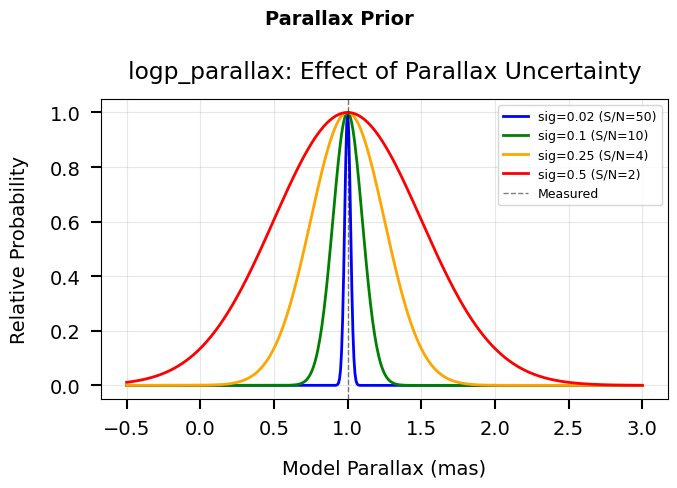


Parallax prior demonstration complete
  Key points:
  - logp_parallax provides Gaussian prior on observed parallax
  - Width of prior controlled by measurement uncertainty
  - At low S/N, the prior becomes broad and asymmetric in distance space


In [5]:
from brutus.priors.astrometric import logp_parallax

# Parallax prior visualization: effect of measurement uncertainty
fig, ax = plt.subplots(figsize=(7, 5))

parallax_grid = np.linspace(-0.5, 3.0, 500)
p_meas = 1.0

for sigma, color, label in [(0.02, 'blue', 'sig=0.02 (S/N=50)'),
                              (0.1, 'green', 'sig=0.1 (S/N=10)'),
                              (0.25, 'orange', 'sig=0.25 (S/N=4)'),
                              (0.5, 'red', 'sig=0.5 (S/N=2)')]:
    lnp = logp_parallax(parallax_grid, p_meas, sigma)
    p = np.exp(lnp - np.max(lnp))
    ax.plot(parallax_grid, p, lw=2, color=color, label=label)

ax.axvline(p_meas, color='black', ls='--', lw=1, alpha=0.5, label='Measured')
ax.set_xlabel('Model Parallax (mas)')
ax.set_ylabel('Relative Probability')
ax.set_title('logp_parallax: Effect of Parallax Uncertainty')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Parallax Prior', fontsize=14, fontweight='bold')
fig.tight_layout()
save_figure(fig, 'parallax_distance')
plt.show()

print("\nParallax prior demonstration complete")
print("  Key points:")
print("  - logp_parallax provides Gaussian prior on observed parallax")
print("  - Width of prior controlled by measurement uncertainty")
print("  - At low S/N, the prior becomes broad and asymmetric in distance space")


## Section 4: Prior Factorization and Combination

The complete prior in brutus combines all components multiplicatively, with proper factorization based on conditional independence.

### Prior Factorization

The full prior can be written as:

P(θ) = P(M) × P(d,Z,τ|l,b) × P(A_V|d,l,b) × P(π_obs|d)

Where:
- P(M): IMF prior on stellar mass
- P(d,Z,τ|l,b): Galactic structure prior (distance, metallicity, age given position)
- P(A_V|d,l,b): 3D dust prior (extinction given distance and position)
- P(π_obs|d): Parallax likelihood (observed parallax given true distance)

  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_04/prior_combination.png


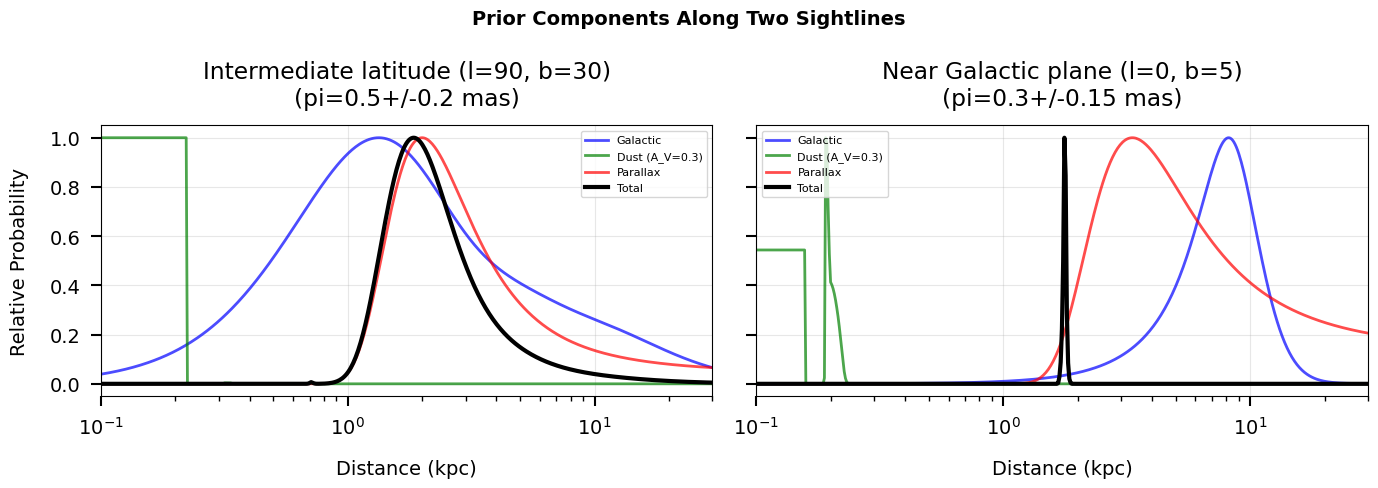


Prior combination demonstrations complete
  Key points:
  - Priors combine multiplicatively
  - Each component provides independent constraints
  - Dust prior uses logp_extinction with distance-resolved Bayestar map
  - Different sightlines show different prior shapes


In [6]:
# Demonstrate prior combination using real brutus prior functions.
# The `dustmap` variable was loaded in the Bayestar cell above.

from brutus.priors.extinction import logp_extinction

# Create combined prior visualization: two sightlines
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Define two sightlines for comparison
sightline_configs = [
    (90, 30, 0.5, 0.2, 'Intermediate latitude (l=90, b=30)'),
    (0, 5, 0.3, 0.15, 'Near Galactic plane (l=0, b=5)'),
]

distances = np.logspace(-1, 1.5, 500)

for ax, (l, b, obs_parallax, sigma_parallax, title) in zip(axes, sightline_configs):
    coord = np.array([l, b])

    # Compute individual prior components using real brutus functions
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        lnp_gal = logp_galactic_structure(distances, coord)

    # 3D dust extinction prior
    av_test = 0.3
    if dust_available and dustmap is not None:
        lnp_dust = logp_extinction(
            np.full_like(distances, av_test), dustmap, coord, distance=distances
        )
        dust_label = f'Dust (A_V={av_test})'
    else:
        av_expected = 0.3 * (1 - np.exp(-distances / 3.0))
        lnp_dust = -0.5 * ((av_test - av_expected) / 0.2)**2
        dust_label = f'Dust (A_V={av_test}, synthetic)'

    # Parallax constraint
    true_parallax = 1.0 / distances
    lnp_par = logp_parallax(true_parallax, obs_parallax, sigma_parallax)

    # Total prior
    lnp_total = lnp_gal + lnp_dust + lnp_par

    # Convert to probabilities for plotting
    p_gal = np.exp(lnp_gal - np.max(lnp_gal))
    p_dust = np.exp(lnp_dust - np.max(lnp_dust))
    p_parallax = np.exp(lnp_par - np.max(lnp_par))
    p_total = np.exp(lnp_total - np.max(lnp_total))

    ax.plot(distances, p_gal, 'b-', lw=2, alpha=0.7, label='Galactic')
    ax.plot(distances, p_dust, 'g-', lw=2, alpha=0.7, label=dust_label)
    ax.plot(distances, p_parallax, 'r-', lw=2, alpha=0.7, label='Parallax')
    ax.plot(distances, p_total, 'k-', lw=3, label='Total')

    ax.set_xlabel('Distance (kpc)')
    ax.set_title(f'{title}\n(pi={obs_parallax}+/-{sigma_parallax} mas)')
    ax.set_xscale('log')
    ax.set_xlim(0.1, 30)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Relative Probability')

plt.suptitle('Prior Components Along Two Sightlines', fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'prior_combination')
plt.show()

print("\nPrior combination demonstrations complete")
print("  Key points:")
print("  - Priors combine multiplicatively")
print("  - Each component provides independent constraints")
print("  - Dust prior uses logp_extinction with distance-resolved Bayestar map")
print("  - Different sightlines show different prior shapes")


## Section 5: Metallicity and Age-Metallicity Priors

Beyond Galactic structure, brutus provides priors on stellar metallicity and an age-metallicity relation that encodes the observed correlation between stellar age and chemical enrichment.

### Metallicity Prior: `logp_feh`

The metallicity prior is a simple Gaussian parameterized by a mean and dispersion, with typical values for each Galactic component:

- **Thin disk**: `feh_mean = -0.2`, `feh_sigma = 0.3`
- **Thick disk**: `feh_mean = -0.7`, `feh_sigma = 0.4`
- **Halo**: `feh_mean = -1.6`, `feh_sigma = 0.5`

### Age-Metallicity Relation: `logp_age_from_feh`

The age prior is conditioned on metallicity through a logistic age-metallicity relation: metal-poor stars are preferentially older, while metal-rich stars are preferentially younger. The mean age and its dispersion are both functions of `feh_mean`, with ages drawn from a truncated normal distribution bounded by physically reasonable limits.

  Saved: /mnt/c/Users/joshs/Dropbox/GitHub/brutus/tutorials/plots/tutorial_04/feh_age_priors.png


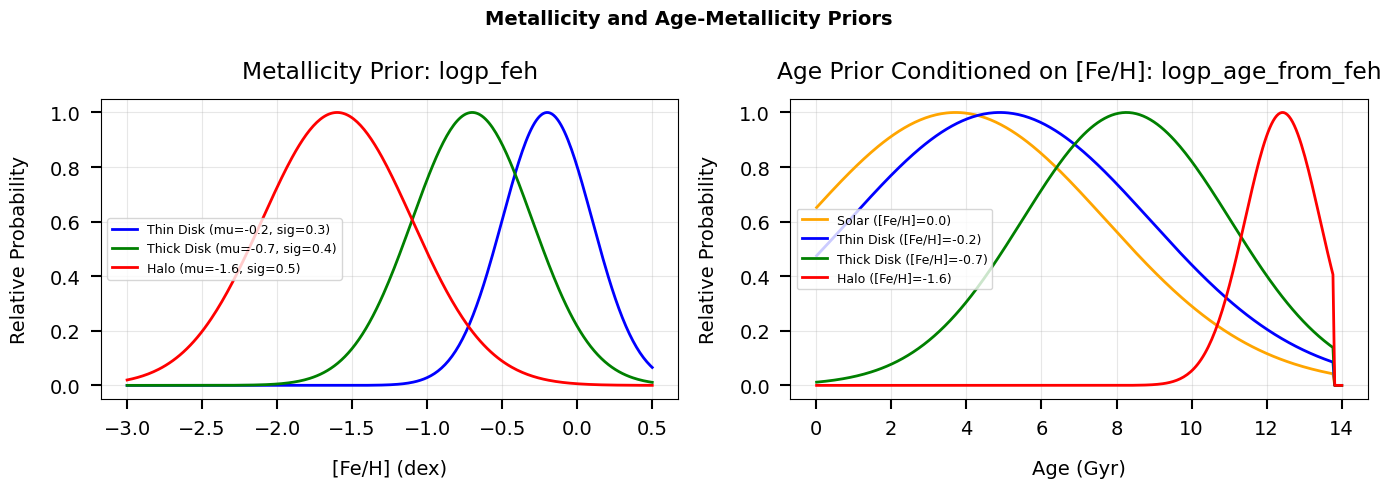


Metallicity & age-metallicity prior demonstrations complete
  Key points:
  - logp_feh is a Gaussian prior on [Fe/H] with component-specific means
  - logp_age_from_feh encodes the age-metallicity relation:
    metal-poor populations are preferentially older
  - The age dispersion narrows for metal-rich (younger) populations


In [7]:
from brutus.priors.galactic import logp_feh, logp_age_from_feh

# --- Panel (a): [Fe/H] distribution for disk vs halo ---
feh_grid = np.linspace(-3, 0.5, 300)

# Typical parameters for Galactic components
components = {
    'Thin Disk':  dict(feh_mean=-0.2, feh_sigma=0.3, color='blue'),
    'Thick Disk': dict(feh_mean=-0.7, feh_sigma=0.4, color='green'),
    'Halo':       dict(feh_mean=-1.6, feh_sigma=0.5, color='red'),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, params in components.items():
    lnp = logp_feh(feh_grid, feh_mean=params['feh_mean'],
                   feh_sigma=params['feh_sigma'])
    prob = np.exp(lnp - np.max(lnp))
    ax1.plot(feh_grid, prob, lw=2, color=params['color'],
             label=f"{name} (mu={params['feh_mean']}, sig={params['feh_sigma']})")

ax1.set_xlabel('[Fe/H] (dex)')
ax1.set_ylabel('Relative Probability')
ax1.set_title('Metallicity Prior: logp_feh')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# --- Panel (b): Age-metallicity relation for different [Fe/H] ---
age_grid = np.linspace(0.01, 14, 300)  # ages in Gyr

feh_values = [0.0, -0.2, -0.7, -1.6]
feh_colors = ['orange', 'blue', 'green', 'red']
feh_labels = ['Solar ([Fe/H]=0.0)', 'Thin Disk ([Fe/H]=-0.2)',
              'Thick Disk ([Fe/H]=-0.7)', 'Halo ([Fe/H]=-1.6)']

for feh_val, color, label in zip(feh_values, feh_colors, feh_labels):
    lnp = logp_age_from_feh(age_grid, feh_mean=feh_val)
    prob = np.exp(lnp - np.max(lnp))
    ax2.plot(age_grid, prob, lw=2, color=color, label=label)

ax2.set_xlabel('Age (Gyr)')
ax2.set_ylabel('Relative Probability')
ax2.set_title('Age Prior Conditioned on [Fe/H]: logp_age_from_feh')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle('Metallicity and Age-Metallicity Priors', fontsize=14,
             fontweight='bold')
fig.tight_layout()
save_figure(fig, 'feh_age_priors')
plt.show()

print("\nMetallicity & age-metallicity prior demonstrations complete")
print("  Key points:")
print("  - logp_feh is a Gaussian prior on [Fe/H] with component-specific means")
print("  - logp_age_from_feh encodes the age-metallicity relation:")
print("    metal-poor populations are preferentially older")
print("  - The age dispersion narrows for metal-rich (younger) populations")

## Summary and Key Takeaways

This tutorial has covered the prior probability distributions used in brutus:

### Key Priors

1. **Galactic Structure**: 3D spatial distribution
   - Thin disk: Young, metal-rich, low scale height
   - Thick disk: Old, metal-poor, high scale height
   - Halo: Very old, very metal-poor, power-law

2. **Dust Maps**: 3D extinction (Bayestar)
   - Provides A(V) as function of distance
   - Higher extinction in Galactic plane
   - Uncertainties increase with distance

3. **Parallax**: Distance constraints from Gaia
   - Non-linear parallax-distance transformation
   - Lutz-Kelker bias pushes distances outward

4. **Metallicity & Age**: Chemical evolution
   - Gaussian [Fe/H] priors per Galactic component
   - Age-metallicity relation encodes enrichment history

### Prior Factorization

The full prior combines multiplicatively:

P(theta) = P(M) x P(d,Z,tau|l,b) x P(A_V|d,l,b) x P(pi_obs|d)

Components are independent given position and observables.

### Next Steps

- **Tutorial 5**: Fitting Individual Stars with BruteForce
- **Tutorial 6**: Cluster Analysis and Population Fitting
- **Tutorial 7**: 3D Dust Mapping

In [8]:
print("Tutorial 4 Complete!")
print("="*60)
print("\nGenerated plots:")
for plot_file in sorted(plots_dir.glob('*.png')):
    print(f"  - {plot_file.name}")

Tutorial 4 Complete!

Generated plots:
  - dust_extinction.png
  - feh_age_priors.png
  - galactic_structure.png
  - parallax_distance.png
  - parallax_scale_prior.png
  - prior_combination.png
